# 11 — TCN + Triple Barrier Method + Multi-Task Learning

Addresses every failure mode from notebooks 05/10 (LSTM/GRU collapse to ~0.5):

| Problem | Fix applied here |
|---|---|
| Noisy binary label (next-close up/down) | **Triple Barrier Method** — path-dependent, dynamic barriers |
| Non-stationary close price input | **Fractional Differentiation** (FFD) — min `d` for stationarity, max memory |
| Outlier sensitivity | **QuantileTransformer** (normal output) on all features |
| RNN hidden-state collapse | **Temporal Convolutional Network** — causal dilated convolutions, stable gradients |
| No training signal (target ≈ random) | **Multi-Task Learning** — auxiliary volatility regression forces meaningful representations |
| Uniform sample importance | **Volatility-weighted loss** — high-vol regimes carry more signal |

**Pipeline:**
1. Fractionally differentiate log-close (find min `d` via ADF test)
2. Triple Barrier labels: `1=up`, `0=down`, `2=flat` (dynamic ±1σ barriers, 12h vertical)
3. Auxiliary target: forward 6h realised volatility
4. Top-50 LGBM features + fracDiff close → QuantileTransformer(normal)
5. TCN (4 residual blocks, dilations 1/2/4/8) → Head A (3-class) + Head B (vol regression)
6. AdamW + cosine-annealing-with-warmup; loss weighted by concurrent volatility
7. Backtest using `P(up)` / `P(down)` as directional signals with ATR-adaptive SL

In [1]:
# ── Data framing ──────────────────────────────────────────────────────────────
SYMBOL   = 'BTCUSDT'
INTERVAL = '1h'

TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

FRAC_D        = 0.4   # fractional differentiation order (validated by ADF below)
FFD_THRES     = 1e-4  # weight truncation threshold for FFD

# Triple Barrier Method
TBM_VOL_WINDOW   = 24    # rolling window (hours) for σ estimate
TBM_PT           = 1.0   # profit-take barrier = entry × (1 + PT × σ)
TBM_SL           = 1.0   # stop-loss barrier   = entry × (1 − SL × σ)
TBM_VERT_H       = 12    # vertical (time) barrier in hours

AUX_FWD_H        = 6     # forward hours for realised vol auxiliary target

# ── Sequences ─────────────────────────────────────────────────────────────────
SEQ_LEN = 24             # 1-day lookback; features already encode longer history

# ── TCN architecture ──────────────────────────────────────────────────────────
TCN_CHANNELS  = [64, 64, 64, 64]   # one entry per residual block
TCN_KERNEL    = 3                  # kernel size (odd); dilations = 2^block_idx
TCN_DROPOUT   = 0.40

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS        = 100
WARMUP_EPOCHS = 5
BATCH_SIZE    = 256
LR            = 2e-3
WEIGHT_DECAY  = 1e-3
PATIENCE      = 15
LAMBDA_VOL    = 0.5    # weight of auxiliary vol-regression loss

# ── Trading ───────────────────────────────────────────────────────────────────
# With 3 classes, probs are split ~1/3 each; thresholds are lower than binary
LONG_THRESHOLD        = 0.40   # enter long  when P(up)   >= this
SHORT_THRESHOLD       = 0.40   # enter short when P(down) >= this
EXIT_THRESHOLD_LONG   = 0.32   # exit long  when P(up)   <  this
EXIT_THRESHOLD_SHORT  = 0.32   # exit short when P(down) <  this

MIN_HOLD_CANDLES = 6
MAX_HOLD_CANDLES = 48
COOLDOWN_CANDLES = 3
ATR_MULTIPLIER   = 2.0
MIN_SL           = 0.015
TAKE_PROFIT      = 0.03

SEED = 42

In [2]:
import json
import math
import random
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.calibration import calibration_curve
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from torch.utils.data import DataLoader, TensorDataset

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():         DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
                                       DEVICE = torch.device('mps')
else:                                  DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9,  'ytick.labelsize': 9,
    'legend.fontsize': 9,  'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350';   GREEN='#26A69A'; PURPLE='#7B1FA2'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
FIGURES_DIR  = REPO_ROOT / 'figures'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists():
    MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
print(f'REPO_ROOT:  {REPO_ROOT}')
print(f'MODELS_DIR: {MODELS_DIR}')

Device: mps
REPO_ROOT:  /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
MODELS_DIR: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models


## 1. Load data & pre-selected features

In [3]:
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

with open(FEATURES_DIR / 'feature_registry.json') as f:
    registry = json.load(f)
BACKTEST_COLS = registry['backtest_only_cols']  # ['close', 'sma_200', 'atr_14_pct']

# Reuse the 50 RF+correlation-filtered features from notebook 06
selected_features = pd.read_csv(MODELS_DIR / 'lgbm_features.csv', header=None)[0].tolist()
missing = [f for f in selected_features if f not in feat_df.columns]
if missing:
    raise ValueError(f'Features missing from parquet: {missing}')

print(f'Loaded {len(feat_df):,} rows  {feat_df.index.min().date()} → {feat_df.index.max().date()}')
print(f'Using {len(selected_features)} pre-selected features + 1 fracDiff close = {len(selected_features)+1} total')

Loaded 74,366 rows  2017-11-15 → 2026-05-16
Using 50 pre-selected features + 1 fracDiff close = 51 total


## 2. Fractional Differentiation (FFD)

Standard returns discard long-memory; raw log-price is non-stationary. **FFD** finds the minimum `d` such that the series passes an ADF unit-root test while retaining maximum historical information.

The weight of lag `k` is $w_k = \prod_{j=1}^{k} \frac{j - d - 1}{j}$, truncated when $|w_k| < $ threshold.

In [4]:
def _ffd_weights(d: float, thres: float = 1e-4) -> np.ndarray:
    """Fixed-width window FFD weights, oldest-to-newest order."""
    w = [1.0]
    k = 1
    while True:
        w_k = -w[-1] / k * (d - k + 1)
        if abs(w_k) < thres:
            break
        w.append(w_k)
        k += 1
    return np.array(w[::-1], dtype=np.float64)  # oldest … newest


def frac_diff_ffd(series: pd.Series, d: float, thres: float = 1e-4) -> pd.Series:
    """Apply FFD to a series; first (width-1) values are NaN."""
    weights = _ffd_weights(d, thres)
    width   = len(weights)
    vals    = series.values.astype(np.float64)
    out     = np.full(len(vals), np.nan)
    for i in range(width - 1, len(vals)):
        out[i] = np.dot(weights, vals[i - width + 1 : i + 1])
    return pd.Series(out, index=series.index, name=f'fracdiff_d{d}')


# ── Find minimum d that achieves stationarity (ADF p < 0.01) ─────────────────
log_close = np.log(feat_df['close'])
d_opt     = FRAC_D   # default

try:
    from statsmodels.tsa.stattools import adfuller
    train_log = log_close[log_close.index < TRAIN_END]
    print('Searching for minimum d (ADF test on training close):')
    for d_test in np.arange(0.1, 1.01, 0.1):
        fd   = frac_diff_ffd(train_log, round(float(d_test), 1), FFD_THRES).dropna()
        pval = adfuller(fd.values, maxlag=1, regression='c', autolag=None)[1]
        marker = '  ← selected' if pval < 0.01 and d_opt == FRAC_D else ''
        print(f'  d={d_test:.1f}  ADF p-value={pval:.4f}{marker}')
        if pval < 0.01 and d_opt == FRAC_D:
            d_opt = round(float(d_test), 1)
except ImportError:
    print(f'statsmodels not available; using default d={d_opt}')

print(f'\nUsing d = {d_opt}')
fracdiff_close = frac_diff_ffd(log_close, d_opt, FFD_THRES)
ffd_nan_rows   = fracdiff_close.isna().sum()
print(f'FFD window = {ffd_nan_rows} rows (leading NaN, will be dropped)')

statsmodels not available; using default d=0.4

Using d = 0.4
FFD window = 281 rows (leading NaN, will be dropped)


## 3. Triple Barrier Method (TBM) labels

For each bar `t`:
- Compute rolling 24h log-return σ
- Upper barrier = `close[t] × (1 + PT_MULT × σ[t])`
- Lower barrier = `close[t] × (1 − SL_MULT × σ[t])`
- Look forward up to `VERT_H` bars:
  - **Label 1** — upper hit first (long signal)
  - **Label 0** — lower hit first (short signal)  
  - **Label 2** — time barrier reached (no clear direction)

Labels use future prices — valid for supervised learning targets, not features.

In [5]:
log_rets   = log_close.diff()
rolling_vol = log_rets.rolling(TBM_VOL_WINDOW).std()   # σ estimate at each bar

close_vals = feat_df['close'].values
vol_vals   = rolling_vol.values
n          = len(close_vals)

tbm_labels = np.full(n, np.nan)

for i in range(n - TBM_VERT_H):
    if np.isnan(vol_vals[i]) or vol_vals[i] <= 0:
        continue
    entry  = close_vals[i]
    upper  = entry * (1.0 + TBM_PT * vol_vals[i])
    lower  = entry * (1.0 - TBM_SL * vol_vals[i])
    label  = 2   # default: time barrier
    for j in range(1, TBM_VERT_H + 1):
        px = close_vals[i + j]
        if px >= upper:
            label = 1; break
        elif px <= lower:
            label = 0; break
    tbm_labels[i] = label

feat_df['tbm_label'] = tbm_labels

# ── Label distribution ────────────────────────────────────────────────────────
valid = feat_df['tbm_label'].dropna()
counts = valid.value_counts().sort_index()
names  = {0: 'Down (0)', 1: 'Up (1)', 2: 'Flat (2)'}
print('TBM label distribution (full dataset):')
for lbl, cnt in counts.items():
    print(f'  {names[lbl]}: {cnt:>7,}  ({cnt/len(valid)*100:.1f}%)')
print(f'  Total valid: {len(valid):,} / {n:,}')
print(f'  Barriers: ±{TBM_PT}σ  |  σ=24h rolling  |  vertical={TBM_VERT_H}h')

TBM label distribution (full dataset):
  Down (0):  34,292  (46.1%)
  Up (1):  35,701  (48.0%)
  Flat (2):   4,337  (5.8%)
  Total valid: 74,330 / 74,366
  Barriers: ±1.0σ  |  σ=24h rolling  |  vertical=12h


### Label distribution plot

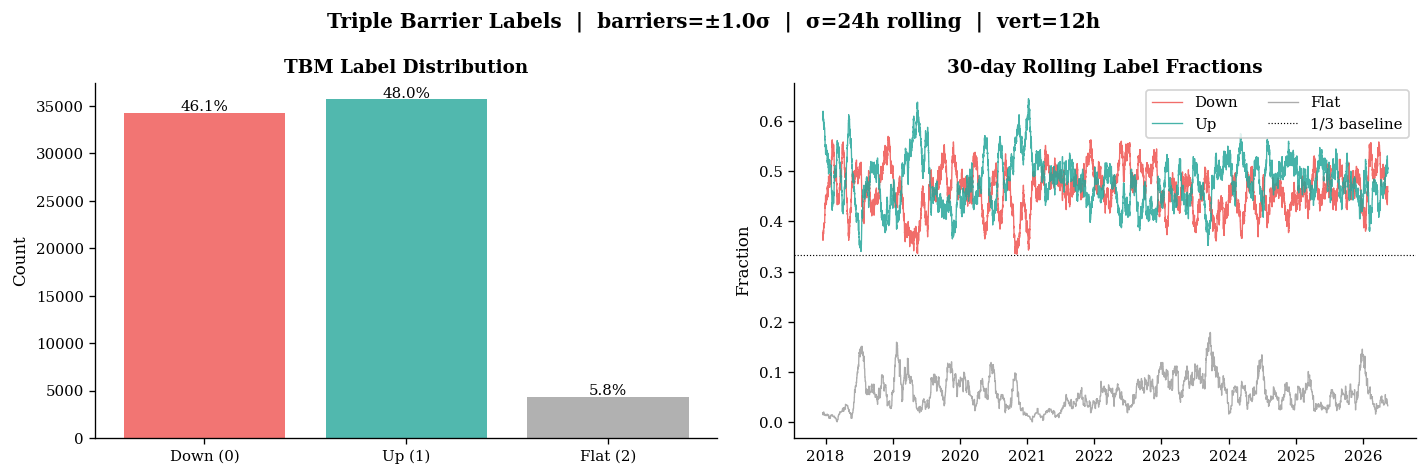

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax = axes[0]
colors = [RED, GREEN, GREY]
bars = ax.bar([names[k] for k in [0,1,2]], [counts.get(k, 0) for k in [0,1,2]], color=colors, alpha=0.8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height()/len(valid)*100:.1f}%', ha='center', fontsize=9)
ax.set_title('TBM Label Distribution', fontweight='bold')
ax.set_ylabel('Count')

# Rolling fraction of each label over time
ax = axes[1]
lbl_series = feat_df['tbm_label'].dropna()
roll_w = 720  # 30-day rolling
for lbl, col, name in [(0, RED, 'Down'), (1, GREEN, 'Up'), (2, GREY, 'Flat')]:
    frac = (lbl_series == lbl).rolling(roll_w).mean()
    ax.plot(frac.index, frac, color=col, lw=0.8, alpha=0.85, label=name)
ax.axhline(1/3, color='black', ls=':', lw=0.7, label='1/3 baseline')
ax.set_title('30-day Rolling Label Fractions', fontweight='bold')
ax.set_ylabel('Fraction'); ax.legend(ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle(f'Triple Barrier Labels  |  barriers=±{TBM_PT}σ  |  σ=24h rolling  |  vert={TBM_VERT_H}h',
             fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'tcn_tbm_label_dist.png')
plt.show()

## 4. Auxiliary target: forward realised volatility

Volatility is strongly autocorrelated (GARCH clustering). The network gets a clear gradient signal from this easy regression task, forcing it to build meaningful market-regime representations before the direction head can ride them.

In [7]:
# Forward AUX_FWD_H realised vol: std of log-returns at t+1 … t+AUX_FWD_H
fwd_vol = pd.concat(
    [log_rets.shift(-h) for h in range(1, AUX_FWD_H + 1)], axis=1
).std(axis=1)
feat_df['fwd_vol'] = fwd_vol

# Sample weight: current 24h vol, clipped to [0.3, 3.0] × mean
curr_vol = rolling_vol.fillna(rolling_vol.median())
w_raw    = curr_vol / curr_vol.median()
feat_df['sample_weight'] = w_raw.clip(0.3, 3.0).fillna(1.0)

print(f'Forward {AUX_FWD_H}h vol   — mean: {fwd_vol.mean()*100:.4f}%  std: {fwd_vol.std()*100:.4f}%')
print(f'Sample weights     — mean: {feat_df["sample_weight"].mean():.3f}  range: [{feat_df["sample_weight"].min():.3f}, {feat_df["sample_weight"].max():.3f}]')

Forward 6h vol   — mean: 0.5588%  std: 0.5196%
Sample weights     — mean: 1.170  range: [0.300, 3.000]


## 5. Feature assembly & calendar split

In [8]:
# Attach fracDiff close as an additional input feature
feat_df['fracdiff_close'] = fracdiff_close
ALL_INPUT_FEATS = selected_features + ['fracdiff_close']

# Drop rows with NaN in any required column
required_cols = ALL_INPUT_FEATS + ['tbm_label', 'fwd_vol', 'sample_weight'] + BACKTEST_COLS
clean_df = feat_df[required_cols].dropna()
print(f'After NaN drop: {len(clean_df):,} rows  (dropped {len(feat_df)-len(clean_df):,})')

train_df, val_df, test_df = calendar_split(clean_df, train_end=TRAIN_END, val_end=VAL_END)
print(f'Train: {len(train_df):>7,}  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'Val:   {len(val_df):>7,}  {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'Test:  {len(test_df):>7,}  {test_df.index.min().date()} → {test_df.index.max().date()}')

# Label distribution per split
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    vc = df['tbm_label'].value_counts(normalize=True).sort_index()
    print(f'  {name}: down={vc.get(0,0)*100:.1f}%  up={vc.get(1,0)*100:.1f}%  flat={vc.get(2,0)*100:.1f}%')

After NaN drop: 74,073 rows  (dropped 293)
Train:  56,949  2017-11-27 → 2024-06-01
Val:     3,888  2024-06-01 → 2024-11-10
Test:   13,236  2024-11-10 → 2026-05-15
  Train: down=46.1%  up=47.9%  flat=6.0%
  Val: down=44.0%  up=49.4%  flat=6.7%
  Test: down=46.9%  up=48.0%  flat=5.1%


## 6. Normalization (QuantileTransformer) & sequence building

`QuantileTransformer(output_distribution='normal')` maps each feature to a standard normal distribution, collapsing outliers that would otherwise dominate gradients in volatile price regimes.

In [9]:
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
X_train_raw = qt.fit_transform(train_df[ALL_INPUT_FEATS].values).astype(np.float32)
X_val_raw   = qt.transform(val_df[ALL_INPUT_FEATS].values).astype(np.float32)
X_test_raw  = qt.transform(test_df[ALL_INPUT_FEATS].values).astype(np.float32)

# Save transformer for inference
import pickle
(MODELS_DIR / 'tcn_qt.pkl').write_bytes(pickle.dumps(qt))
pd.Series(ALL_INPUT_FEATS).to_csv(MODELS_DIR / 'tcn_features.csv', index=False, header=False)

def make_sequences(X_norm, y_dir, y_vol, weights, seq_len=SEQ_LEN):
    """Build (X, y_dir, y_vol, w) arrays; first seq_len rows consumed as lookback."""
    Xs, yd, yv, ws = [], [], [], []
    for i in range(seq_len, len(X_norm)):
        Xs.append(X_norm[i - seq_len : i])
        yd.append(y_dir[i])
        yv.append(y_vol[i])
        ws.append(weights[i])
    return (np.array(Xs, dtype=np.float32),
            np.array(yd, dtype=np.int64),
            np.array(yv, dtype=np.float32),
            np.array(ws, dtype=np.float32))

X_tr, y_tr_dir, y_tr_vol, w_tr = make_sequences(
    X_train_raw, train_df['tbm_label'].values.astype(int),
    train_df['fwd_vol'].values, train_df['sample_weight'].values)

X_vl, y_vl_dir, y_vl_vol, w_vl = make_sequences(
    X_val_raw, val_df['tbm_label'].values.astype(int),
    val_df['fwd_vol'].values, val_df['sample_weight'].values)

X_te, y_te_dir, y_te_vol, w_te = make_sequences(
    X_test_raw, test_df['tbm_label'].values.astype(int),
    test_df['fwd_vol'].values, test_df['sample_weight'].values)

print(f'X_train: {X_tr.shape}  X_val: {X_vl.shape}  X_test: {X_te.shape}')
print(f'  → each sample = {SEQ_LEN}h × {len(ALL_INPUT_FEATS)} features')

# Class weights for weighted cross-entropy (inverse frequency)
from collections import Counter
cnt = Counter(y_tr_dir.tolist())
total = sum(cnt.values())
class_weights = torch.tensor(
    [total / (3 * cnt.get(c, 1)) for c in range(3)], dtype=torch.float32
).to(DEVICE)
print(f'Class weights: down={class_weights[0]:.3f}  up={class_weights[1]:.3f}  flat={class_weights[2]:.3f}')

X_train: (56925, 24, 51)  X_val: (3864, 24, 51)  X_test: (13212, 24, 51)
  → each sample = 24h × 51 features
Class weights: down=0.722  up=0.696  flat=5.601


## 7. TCN architecture

```
Input  (B, T, F)  →  transpose →  (B, F, T)
  Block 1: CausalConv(dil=1) × 2 + residual  →  (B, 64, T)
  Block 2: CausalConv(dil=2) × 2 + residual  →  (B, 64, T)
  Block 3: CausalConv(dil=4) × 2 + residual  →  (B, 64, T)
  Block 4: CausalConv(dil=8) × 2 + residual  →  (B, 64, T)
  Last timestep  →  (B, 64)
  ├── Head A: Linear → Softmax3  (Up / Down / Flat)
  └── Head B: Linear → Softplus  (forward realised vol)
```

Receptive field with kernel=3, dilations [1,2,4,8]: `1 + 2×(3-1)×(1+2+4+8) = 61 > 24` — sees entire sequence.

In [10]:
class CausalConv1d(nn.Module):
    """Causal (left-padded) dilated Conv1d with WeightNorm."""
    def __init__(self, in_ch: int, out_ch: int, kernel: int, dilation: int):
        super().__init__()
        self.pad  = (kernel - 1) * dilation
        self.conv = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=self.pad)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.conv(x)
        return out[:, :, :-self.pad] if self.pad > 0 else out  # remove future padding


class TCNBlock(nn.Module):
    """Two causal convs + dropout + residual connection."""
    def __init__(self, in_ch: int, out_ch: int, kernel: int, dilation: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch, out_ch, kernel, dilation),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            CausalConv1d(out_ch, out_ch, kernel, dilation),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        res = self.downsample(x) if self.downsample is not None else x
        return F.relu(self.net(x) + res)


class TCNMultiTask(nn.Module):
    """TCN with dual heads: 3-class direction + volatility regression."""

    def __init__(self, input_dim: int, channels: list, kernel: int, dropout: float):
        super().__init__()
        blocks = []
        in_ch  = input_dim
        for i, out_ch in enumerate(channels):
            blocks.append(TCNBlock(in_ch, out_ch, kernel, dilation=2**i, dropout=dropout))
            in_ch = out_ch
        self.tcn = nn.Sequential(*blocks)

        d = channels[-1]
        self.head_dir = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, 32),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(32, 3),              # logits: [down, up, flat]
        )
        self.head_vol = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, 16),
            nn.GELU(),
            nn.Linear(16, 1),
            nn.Softplus(),                 # vol is always positive
        )

    def forward(self, x: torch.Tensor):
        # x: (B, T, F) → (B, F, T) for Conv1d
        out  = self.tcn(x.transpose(1, 2))    # (B, C, T)
        last = out[:, :, -1]                   # last timestep: (B, C)
        return self.head_dir(last), self.head_vol(last).squeeze(-1)


model = TCNMultiTask(
    input_dim = len(ALL_INPUT_FEATS),
    channels  = TCN_CHANNELS,
    kernel    = TCN_KERNEL,
    dropout   = TCN_DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {n_params:,}')

# Receptive field check
rf = 1 + 2 * (TCN_KERNEL - 1) * sum(2**i for i in range(len(TCN_CHANNELS)))
print(f'Receptive field: {rf} timesteps  (SEQ_LEN={SEQ_LEN}  — {"OK: RF > SEQ_LEN" if rf >= SEQ_LEN else "WARNING: RF < SEQ_LEN"})')

TCNMultiTask(
  (tcn): Sequential(
    (0): TCNBlock(
      (net): Sequential(
        (0): CausalConv1d(
          (conv): Conv1d(51, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        )
        (1): ReLU(inplace=True)
        (2): Dropout(p=0.4, inplace=False)
        (3): CausalConv1d(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        )
        (4): ReLU(inplace=True)
        (5): Dropout(p=0.4, inplace=False)
      )
      (downsample): Conv1d(51, 64, kernel_size=(1,), stride=(1,))
    )
    (1): TCNBlock(
      (net): Sequential(
        (0): CausalConv1d(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        )
        (1): ReLU(inplace=True)
        (2): Dropout(p=0.4, inplace=False)
        (3): CausalConv1d(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        )
        (4): ReLU(inplace=True)
        (5): Dropout(p=0.4, inplace=False)
      )

## 8. Multi-task training

**Loss:** $\mathcal{L} = \mathcal{L}_{\text{CE}}^{\text{weighted}} + \lambda \cdot \mathcal{L}_{\text{Huber}}^{\text{weighted}}$

- $\mathcal{L}_{\text{CE}}$: class-weighted cross-entropy (handles label imbalance)
- $\mathcal{L}_{\text{Huber}}$: robust regression on forward realised vol
- Both losses are weighted by concurrent market volatility: high-vol bars get larger gradient
- **LR schedule:** linear warmup → cosine annealing

In [11]:
train_ds = TensorDataset(
    torch.from_numpy(X_tr), torch.from_numpy(y_tr_dir),
    torch.from_numpy(y_tr_vol), torch.from_numpy(w_tr),
)
val_ds = TensorDataset(
    torch.from_numpy(X_vl), torch.from_numpy(y_vl_dir),
    torch.from_numpy(y_vl_vol), torch.from_numpy(w_vl),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch: int) -> float:
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def step(batch, training: bool):
    xb, yb_dir, yb_vol, wb = [t.to(DEVICE) for t in batch]
    logits, vol_pred = model(xb)

    # Direction: class-weighted CE per sample, then vol-weighted mean
    ce_per = F.cross_entropy(logits, yb_dir, weight=class_weights, reduction='none')
    loss_dir = (ce_per * wb).mean()

    # Volatility: Huber per sample, then vol-weighted mean
    hub_per = F.huber_loss(vol_pred, yb_vol, reduction='none')
    loss_vol = (hub_per * wb).mean()

    loss = loss_dir + LAMBDA_VOL * loss_vol

    if training:
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    acc = (logits.argmax(1) == yb_dir).float().mean().item()
    return loss.item(), loss_dir.item(), loss_vol.item(), acc


history = {k: [] for k in ['tl', 'vl', 'ta', 'va', 'tld', 'vld']}
best_vl, patience_cnt, best_state = float('inf'), 0, None
stopped_epoch = EPOCHS

for epoch in range(1, EPOCHS + 1):
    model.train()
    tl = tld = tvl = ta = n_tr = 0
    for batch in train_loader:
        l, ld, lv, acc = step(batch, training=True)
        bs = len(batch[0])
        tl += l * bs; tld += ld * bs; tvl += lv * bs; ta += acc * bs; n_tr += bs

    model.eval()
    vl = vld = ta2 = n_vl = 0
    with torch.no_grad():
        for batch in val_loader:
            l, ld, lv, acc = step(batch, training=False)
            bs = len(batch[0])
            vl += l * bs; vld += ld * bs; ta2 += acc * bs; n_vl += bs

    tl /= n_tr; vl /= n_vl; tld /= n_tr; vld /= n_vl
    ta /= n_tr; ta2 /= n_vl
    lr_now = optimizer.param_groups[0]['lr']

    history['tl'].append(tl);  history['vl'].append(vl)
    history['ta'].append(ta);  history['va'].append(ta2)
    history['tld'].append(tld); history['vld'].append(vld)

    scheduler.step()

    if vl < best_vl:
        best_vl = vl
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            stopped_epoch = epoch
            print(f'Early stop at epoch {epoch}  (best val loss: {best_vl:.5f})')
            break

    if epoch % 5 == 0 or epoch == 1:
        print(f'Ep {epoch:>3}/{EPOCHS}  '
              f'total: tr={tl:.4f} vl={vl:.4f}  '
              f'dir: tr={tld:.4f} vl={vld:.4f}  '
              f'acc: tr={ta:.4f} vl={ta2:.4f}  lr={lr_now:.2e}')

model.load_state_dict(best_state)
torch.save(model.state_dict(), MODELS_DIR / 'tcn_model.pt')
print(f'\nBest model saved  (val_loss={best_vl:.5f})')

Ep   1/100  total: tr=1.3887 vl=1.0804  dir: tr=1.3656 vl=1.0798  acc: tr=0.3010 vl=0.3846  lr=4.00e-04
Ep   5/100  total: tr=1.2137 vl=1.0286  dir: tr=1.2136 vl=1.0286  acc: tr=0.4259 vl=0.3388  lr=2.00e-03
Ep  10/100  total: tr=1.1305 vl=1.0141  dir: tr=1.1304 vl=1.0141  acc: tr=0.4549 vl=0.3960  lr=1.99e-03
Ep  15/100  total: tr=1.0463 vl=1.0591  dir: tr=1.0462 vl=1.0591  acc: tr=0.4740 vl=0.4001  lr=1.96e-03
Ep  20/100  total: tr=0.9802 vl=1.2554  dir: tr=0.9802 vl=1.2554  acc: tr=0.4928 vl=0.4146  lr=1.89e-03
Early stop at epoch 22  (best val loss: 1.00860)

Best model saved  (val_loss=1.00860)


### Training curves

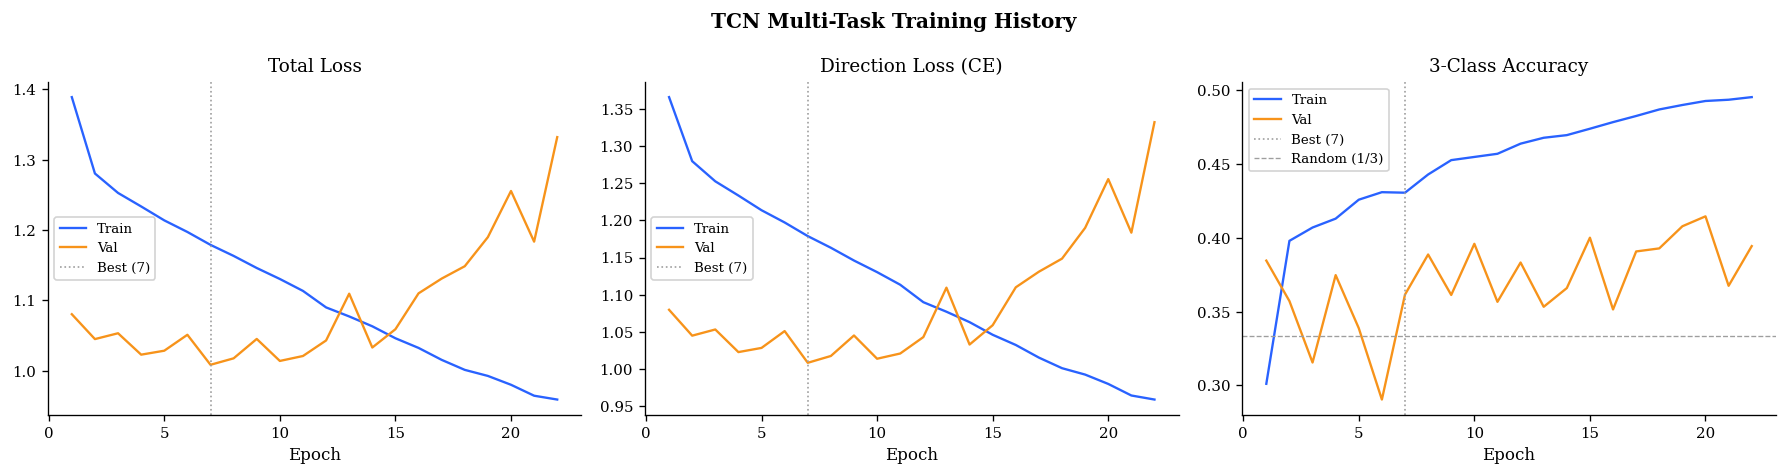

Best epoch: 7
  Train acc: 0.4306   Val acc: 0.3615
  Overfitting gap: 0.0691


In [12]:
best_ep  = stopped_epoch - patience_cnt
ran      = range(1, len(history['tl']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, tk, vk, title in [
    (axes[0], 'tl',  'vl',  'Total Loss'),
    (axes[1], 'tld', 'vld', 'Direction Loss (CE)'),
    (axes[2], 'ta',  'va',  '3-Class Accuracy'),
]:
    ax.plot(ran, history[tk], color=BLUE,   lw=1.4, label='Train')
    ax.plot(ran, history[vk], color=ACCENT, lw=1.4, label='Val')
    ax.axvline(best_ep, color=GREY, ls=':', lw=1, label=f'Best ({best_ep})')
    if 'Acc' in title:
        ax.axhline(1/3, color=GREY, ls='--', lw=0.8, label='Random (1/3)')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(fontsize=8)

fig.suptitle('TCN Multi-Task Training History', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'tcn_training_history.png')
plt.show()

bv = best_ep - 1
print(f'Best epoch: {best_ep}')
print(f'  Train acc: {history["ta"][bv]:.4f}   Val acc: {history["va"][bv]:.4f}')
print(f'  Overfitting gap: {history["ta"][bv]-history["va"][bv]:.4f}')

## 9. Test-set evaluation

In [13]:
model.eval()
all_logits, all_vol_pred = [], []
test_tensor = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te_dir),
                             torch.from_numpy(y_te_vol), torch.from_numpy(w_te))
with torch.no_grad():
    for batch in DataLoader(test_tensor, batch_size=BATCH_SIZE):
        xb = batch[0].to(DEVICE)
        logits, vp = model(xb)
        all_logits.append(logits.cpu())
        all_vol_pred.append(vp.cpu())

logits_test  = torch.cat(all_logits).numpy()           # (N, 3)
probs_test   = torch.softmax(torch.from_numpy(logits_test), dim=1).numpy()  # (N, 3)
probs_down   = probs_test[:, 0]   # P(lower barrier hit first)
probs_up     = probs_test[:, 1]   # P(upper barrier hit first)
probs_flat   = probs_test[:, 2]   # P(time barrier)
pred_cls     = probs_test.argmax(1)

acc_3cls = (pred_cls == y_te_dir).mean()
# Binary direction accuracy (ignore flat class)
binary_mask = y_te_dir != 2
acc_bin  = (pred_cls[binary_mask] == y_te_dir[binary_mask]).mean()

print(f'Test 3-class accuracy : {acc_3cls:.4f}  (random baseline: {1/3:.4f})')
print(f'Test binary accuracy  : {acc_bin:.4f}  (up/down only, flat bars excluded)')
try:
    from sklearn.preprocessing import label_binarize
    y_bin = label_binarize(y_te_dir, classes=[0, 1, 2])
    print(f'Macro AUC             : {roc_auc_score(y_bin, probs_test, multi_class="ovr", average="macro"):.4f}')
except Exception:
    pass
print()
print(classification_report(y_te_dir, pred_cls, target_names=['Down(0)', 'Up(1)', 'Flat(2)']))
print(f'\nP(up)   range: [{probs_up.min():.4f}, {probs_up.max():.4f}]   mean={probs_up.mean():.4f}')
print(f'P(down) range: [{probs_down.min():.4f}, {probs_down.max():.4f}]   mean={probs_down.mean():.4f}')

Test 3-class accuracy : 0.3649  (random baseline: 0.3333)
Test binary accuracy  : 0.3478  (up/down only, flat bars excluded)
Macro AUC             : 0.6030

              precision    recall  f1-score   support

     Down(0)       0.49      0.47      0.48      6205
       Up(1)       0.53      0.23      0.32      6328
     Flat(2)       0.10      0.68      0.18       679

    accuracy                           0.36     13212
   macro avg       0.37      0.46      0.33     13212
weighted avg       0.49      0.36      0.39     13212


P(up)   range: [0.0144, 0.6269]   mean=0.3408
P(down) range: [0.0143, 0.5702]   mean=0.3562


### Confidence distribution

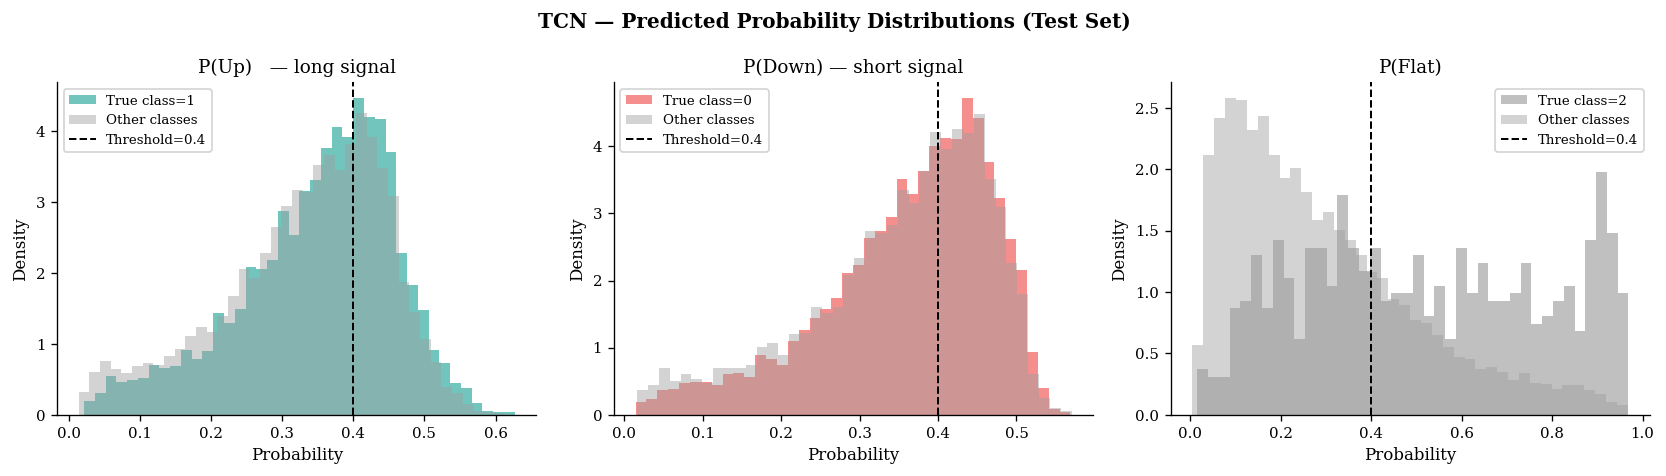

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, prob, actual_cls, title, thr, col_sig in [
    (axes[0], probs_up,   1, 'P(Up)   — long signal',  LONG_THRESHOLD,  GREEN),
    (axes[1], probs_down, 0, 'P(Down) — short signal', SHORT_THRESHOLD, RED),
    (axes[2], probs_flat, 2, 'P(Flat)',                 0.4,             GREY),
]:
    ax.hist(prob[y_te_dir == actual_cls],  bins=40, alpha=0.65, color=col_sig,
            label=f'True class={actual_cls}', density=True)
    ax.hist(prob[y_te_dir != actual_cls],  bins=40, alpha=0.45, color=GREY,
            label=f'Other classes', density=True)
    ax.axvline(thr, color='black', ls='--', lw=1.2, label=f'Threshold={thr}')
    ax.set_xlabel('Probability'); ax.set_ylabel('Density')
    ax.set_title(title); ax.legend(fontsize=8)

fig.suptitle('TCN — Predicted Probability Distributions (Test Set)', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'tcn_confidence_dist.png')
plt.show()

### Win rate by confidence bucket

Key diagnostic: do high P(up) buckets actually have high directional win rates? If yes, the model has learned a tradeable signal.

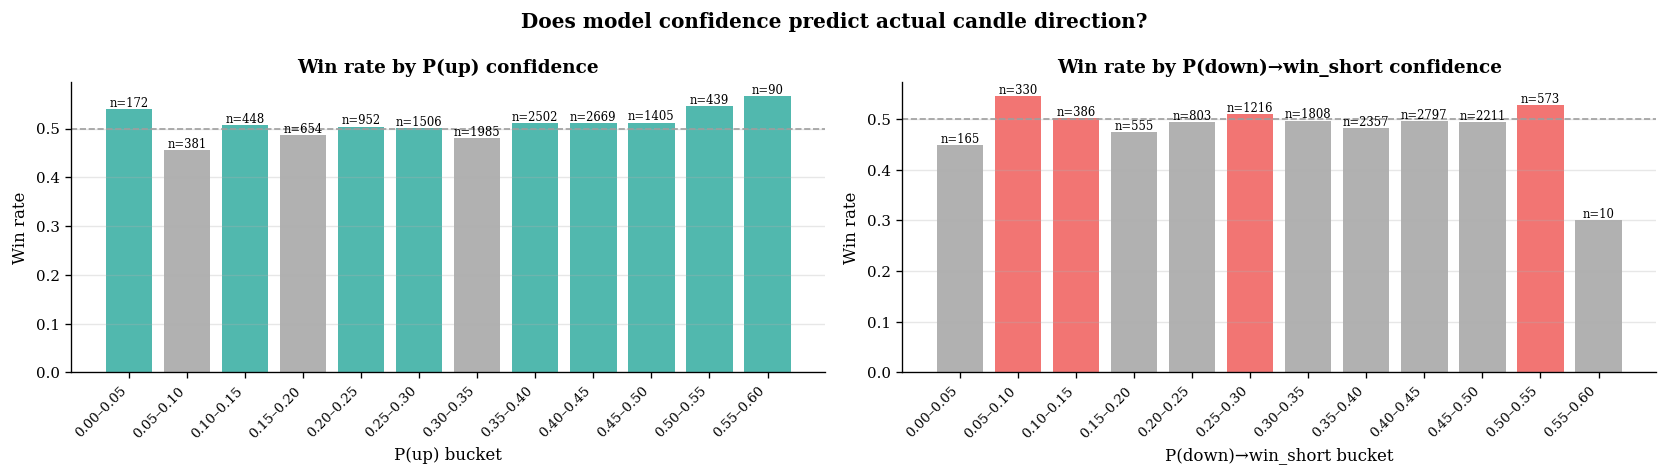

   bucket    n  win_long              type
0.00–0.05  172  0.540698             P(up)
0.05–0.10  381  0.456693             P(up)
0.10–0.15  448  0.506696             P(up)
0.15–0.20  654  0.486239             P(up)
0.20–0.25  952  0.504202             P(up)
0.25–0.30 1506  0.500664             P(up)
0.30–0.35 1985  0.481108             P(up)
0.35–0.40 2502  0.510791             P(up)
0.40–0.45 2669  0.511802             P(up)
0.45–0.50 1405  0.512456             P(up)
0.50–0.55  439  0.546697             P(up)
0.55–0.60   90  0.566667             P(up)
0.00–0.05  165  0.448485 P(down)→win_short
0.05–0.10  330  0.545455 P(down)→win_short
0.10–0.15  386  0.502591 P(down)→win_short
0.15–0.20  555  0.473874 P(down)→win_short
0.20–0.25  803  0.494396 P(down)→win_short
0.25–0.30 1216  0.509868 P(down)→win_short
0.30–0.35 1808  0.497235 P(down)→win_short
0.35–0.40 2357  0.481969 P(down)→win_short
0.40–0.45 2797  0.496604 P(down)→win_short
0.45–0.50 2211  0.493894 P(down)→win_short
0.50–0.55  

In [15]:
# Use NEXT-candle actual direction (original binary label from the parquet) for win-rate
# TBM label 2 = flat, so for win-rate analysis on actual bar returns we use:
#   win_long[i] = 1 if close[t+1] > close[t]  (independently of TBM)
actual_up_arr = (test_df['close'].values[SEQ_LEN + 1:] > test_df['close'].values[SEQ_LEN:-1]).astype(int)
n_common = min(len(actual_up_arr), len(probs_up))
pu = probs_up[:n_common]
pd_ = probs_down[:n_common]
au = actual_up_arr[:n_common]

rows = []
for lo in np.arange(0.0, 0.95, 0.05):
    hi = lo + 0.05
    mask = (pu >= lo) & (pu < hi)
    if mask.sum() < 10: continue
    rows.append({'bucket': f'{lo:.2f}–{hi:.2f}', 'n': mask.sum(),
                 'win_long': au[mask].mean(), 'type': 'P(up)'})

for lo in np.arange(0.0, 0.95, 0.05):
    hi = lo + 0.05
    mask = (pd_ >= lo) & (pd_ < hi)
    if mask.sum() < 10: continue
    rows.append({'bucket': f'{lo:.2f}–{hi:.2f}', 'n': mask.sum(),
                 'win_long': 1 - au[mask].mean(), 'type': 'P(down)→win_short'})

bkt = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, type_label, color in [
    (axes[0], 'P(up)',                GREEN),
    (axes[1], 'P(down)→win_short',    RED),
]:
    sub = bkt[bkt['type'] == type_label].reset_index(drop=True)
    if sub.empty:
        ax.set_title(f'{type_label} — no data'); continue
    bar_colors = [color if r > 0.5 else GREY for r in sub['win_long']]
    ax.bar(range(len(sub)), sub['win_long'], color=bar_colors, alpha=0.8)
    ax.axhline(0.5, color=GREY, ls='--', lw=1)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['bucket'], rotation=45, ha='right', fontsize=8)
    for i, row in sub.iterrows():
        ax.text(i, row['win_long'] + 0.005, f'n={row["n"]}', ha='center', fontsize=7)
    ax.set_xlabel(f'{type_label} bucket'); ax.set_ylabel('Win rate')
    ax.set_title(f'Win rate by {type_label} confidence', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Does model confidence predict actual candle direction?', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'tcn_win_rate_by_bucket.png')
plt.show()
print(bkt.to_string(index=False))

## 10. Backtest — Long & Short

Same ATR-adaptive SL + TP engine as notebook 06. **Directional signals use TBM class probabilities:**
- Long: `P(up) ≥ LONG_THRESHOLD`
- Short: `P(down) ≥ SHORT_THRESHOLD`

Exit: SL → TP → max hold → confidence exit (after min hold)

> TBM was used only for training. The backtest evaluates real trading P&L, independent of TBM labels.

In [16]:
sig_index = test_df.index[SEQ_LEN:SEQ_LEN + len(probs_up)]
close_arr = test_df['close'].values[SEQ_LEN:SEQ_LEN + len(probs_up)]
atr_arr   = test_df['atr_14_pct'].values[SEQ_LEN:SEQ_LEN + len(probs_up)]

cash = 1.0; units = 0.0
in_pos = False; direction = None
entry_px = 0.0; entry_ts = None
entry_cash = 0.0; dynamic_sl = 0.0
hold_count = 0; cooldown = 0

equity_curve = [1.0]
trade_log    = []

for ts, px, p_up, p_dn, atr_pct in zip(
    sig_index, close_arr, probs_up, probs_down, atr_arr
):
    if cooldown > 0:
        cooldown -= 1

    if in_pos:
        hold_count += 1
        pnl    = (px - entry_px)/entry_px if direction=='long' \
                 else (entry_px - px)/entry_px
        reason = None
        if   pnl <= -dynamic_sl:                                          reason = 'sl'
        elif pnl >= TAKE_PROFIT:                                          reason = 'tp'
        elif hold_count >= MAX_HOLD_CANDLES:                              reason = 'max_hold'
        elif hold_count >= MIN_HOLD_CANDLES:
            if   direction == 'long'  and p_up < EXIT_THRESHOLD_LONG:    reason = 'conf'
            elif direction == 'short' and p_dn < EXIT_THRESHOLD_SHORT:   reason = 'conf'

        if reason:
            cash  = units * px if direction == 'long' else entry_cash * (1 + pnl)
            units = 0.0
            trade_log.append({'entry_time': entry_ts, 'exit_time': ts,
                               'direction': direction, 'entry_px': entry_px, 'exit_px': px,
                               'pnl_pct': pnl, 'reason': reason, 'hold_h': hold_count,
                               'dynamic_sl': dynamic_sl})
            in_pos = False; direction = None
            hold_count = 0; cooldown = COOLDOWN_CANDLES

    if not in_pos and cooldown == 0:
        sl = max(ATR_MULTIPLIER * atr_pct, MIN_SL)
        if p_up >= LONG_THRESHOLD:
            units = cash / px; cash = 0.0; in_pos = True; direction = 'long'
            entry_px = px; entry_ts = ts; hold_count = 0; dynamic_sl = sl
        elif p_dn >= SHORT_THRESHOLD and p_up < LONG_THRESHOLD:
            entry_cash = cash; units = cash / px
            in_pos = True; direction = 'short'
            entry_px = px; entry_ts = ts; hold_count = 0; dynamic_sl = sl

    if in_pos and direction == 'long':
        equity_curve.append(units * px)
    elif in_pos and direction == 'short':
        equity_curve.append(entry_cash * (1 + (entry_px - px)/entry_px))
    else:
        equity_curve.append(cash)

if in_pos:
    px  = close_arr[-1]
    pnl = (px - entry_px)/entry_px if direction=='long' else (entry_px - px)/entry_px
    trade_log.append({'entry_time': entry_ts, 'exit_time': sig_index[-1],
                      'direction': direction, 'entry_px': entry_px, 'exit_px': px,
                      'pnl_pct': pnl, 'reason': 'eod', 'hold_h': hold_count,
                      'dynamic_sl': dynamic_sl})
    equity_curve[-1] = entry_cash*(1+pnl) if direction=='short' else units*px

equity_arr = np.array(equity_curve[1:])
trades_df  = pd.DataFrame(trade_log)

print(f'Total trades: {len(trades_df)}')
if not trades_df.empty:
    print(trades_df.groupby(['direction', 'reason']).size().to_string())
    print(f'Avg SL: {trades_df["dynamic_sl"].mean()*100:.2f}%   Avg hold: {trades_df["hold_h"].mean():.1f}h')
else:
    print(f'\nNo trades generated.')
    print(f'P(up)   — fraction ≥ {LONG_THRESHOLD}: {(probs_up  >= LONG_THRESHOLD).mean()*100:.1f}%')
    print(f'P(down) — fraction ≥ {SHORT_THRESHOLD}: {(probs_down >= SHORT_THRESHOLD).mean()*100:.1f}%')
    print('→ Lower LONG_THRESHOLD / SHORT_THRESHOLD based on the win-rate-by-bucket plot.')

Total trades: 534
direction  reason  
long       conf        146
           max_hold      5
           sl           79
           tp           26
short      conf        165
           max_hold     11
           sl           79
           tp           23
Avg SL: 1.75%   Avg hold: 14.3h


## 11. Buy-and-hold benchmark

In [17]:
bh_units  = 1.0 / close_arr[0]
bh_equity = bh_units * close_arr
bh_final  = bh_equity[-1]

## 12. Metrics

In [18]:
def sharpe(eq, ann=24*365):
    r = np.log(eq[1:] / (eq[:-1] + 1e-12))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(ann)) if len(r) > 1 else 0.0

def max_dd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())

long_t  = trades_df[trades_df['direction']=='long']  if not trades_df.empty else pd.DataFrame()
short_t = trades_df[trades_df['direction']=='short'] if not trades_df.empty else pd.DataFrame()

metrics = pd.DataFrame([
    {'Strategy':      'TCN (TBM + MTL)',
     'Total Return':  f'{(equity_arr[-1]-1)*100:.2f}%',
     'Sharpe (ann.)': f'{sharpe(equity_arr):.3f}',
     'Max Drawdown':  f'{max_dd(equity_arr)*100:.2f}%',
     'Trades (L/S)':  f'{len(long_t)}/{len(short_t)}',
     'Win Rate':      f'{(trades_df["pnl_pct"]>0).mean()*100:.1f}%' if not trades_df.empty else 'N/A',
     'Avg Hold (h)':  f'{trades_df["hold_h"].mean():.1f}' if not trades_df.empty else 'N/A',
    },
    {'Strategy':      'Buy & Hold',
     'Total Return':  f'{(bh_final-1)*100:.2f}%',
     'Sharpe (ann.)': f'{sharpe(bh_equity):.3f}',
     'Max Drawdown':  f'{max_dd(bh_equity)*100:.2f}%',
     'Trades (L/S)':  '1/0', 'Win Rate': 'N/A', 'Avg Hold (h)': 'N/A',
    },
]).set_index('Strategy')
print(metrics.to_string())

                Total Return Sharpe (ann.) Max Drawdown Trades (L/S) Win Rate Avg Hold (h)
Strategy                                                                                  
TCN (TBM + MTL)       -4.21%        -0.082      -41.95%      256/278    50.9%         14.3
Buy & Hold            -1.02%        -0.015      -50.08%          1/0      N/A          N/A


## 13. Results plot

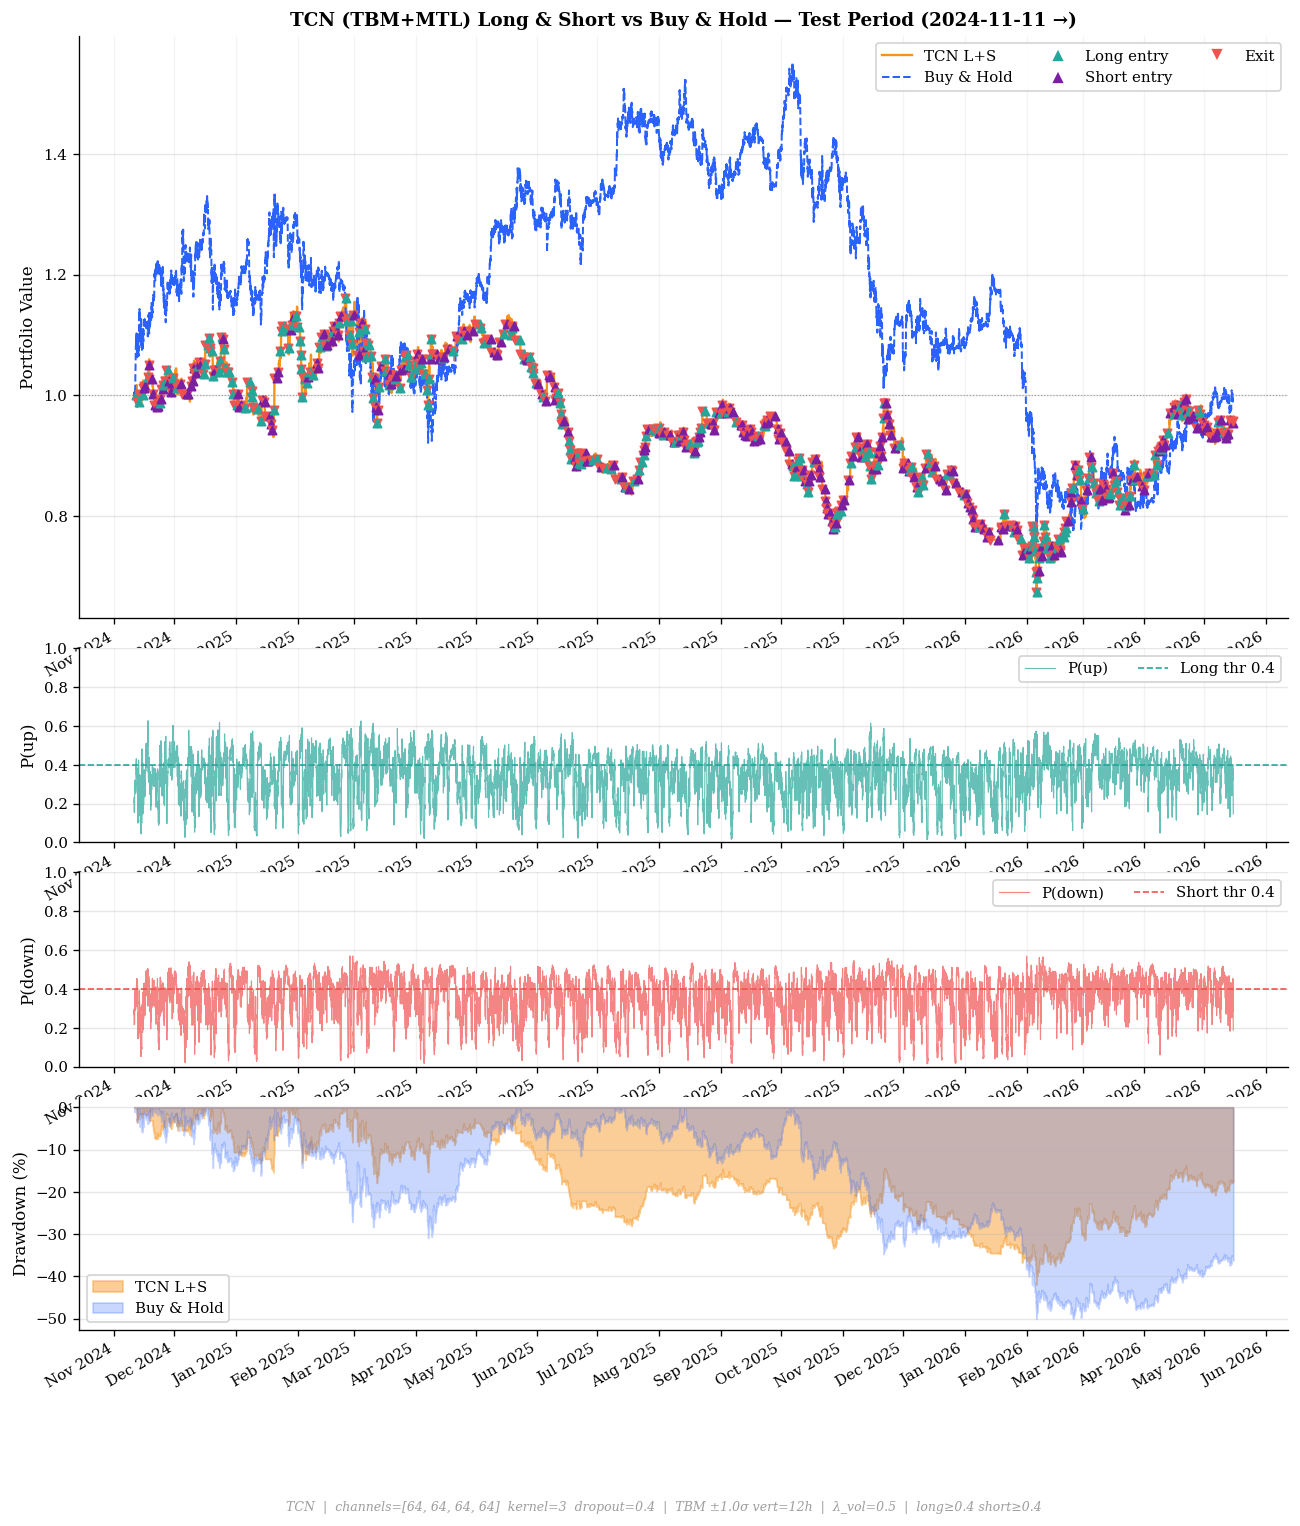

In [19]:
fig, axes = plt.subplots(4, 1, figsize=(13, 14),
                         gridspec_kw={'height_ratios': [3, 1, 1, 1.2], 'hspace': 0.10})

# ── Equity ────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(sig_index, equity_arr, color=ACCENT, lw=1.4, label='TCN L+S')
ax.plot(sig_index, bh_equity,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
if not trades_df.empty:
    eq_s = pd.Series(equity_arr, index=sig_index)
    for _, row in trades_df.iterrows():
        ei = eq_s.index.get_indexer([row['entry_time']], method='nearest')[0]
        xi = eq_s.index.get_indexer([row['exit_time']],  method='nearest')[0]
        col = GREEN if row['direction']=='long' else PURPLE
        ax.scatter(eq_s.index[ei], equity_arr[ei], marker='^', color=col, s=25, zorder=5)
        ax.scatter(eq_s.index[xi], equity_arr[xi], marker='v', color=RED,  s=25, zorder=5)
    from matplotlib.lines import Line2D
    ax.legend(handles=list(ax.get_legend_handles_labels()[0]) + [
        Line2D([0],[0],marker='^',color='w',markerfacecolor=GREEN, markersize=8,label='Long entry'),
        Line2D([0],[0],marker='^',color='w',markerfacecolor=PURPLE,markersize=8,label='Short entry'),
        Line2D([0],[0],marker='v',color='w',markerfacecolor=RED,   markersize=8,label='Exit'),
    ], ncol=3)
ax.set_ylabel('Portfolio Value'); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)
ax.set_title(f'TCN (TBM+MTL) Long & Short vs Buy & Hold — Test Period ({sig_index.min().date()} →)',
             fontweight='bold')

# ── P(up) ─────────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(sig_index, probs_up,   color=GREEN, lw=0.7, alpha=0.7, label='P(up)')
ax.axhline(LONG_THRESHOLD, color=GREEN, ls='--', lw=1, label=f'Long thr {LONG_THRESHOLD}')
ax.set_ylim(0, 1); ax.set_ylabel('P(up)'); ax.legend(ncol=2)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# ── P(down) ───────────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(sig_index, probs_down, color=RED,  lw=0.7, alpha=0.7, label='P(down)')
ax.axhline(SHORT_THRESHOLD, color=RED,   ls='--', lw=1, label=f'Short thr {SHORT_THRESHOLD}')
ax.set_ylim(0, 1); ax.set_ylabel('P(down)'); ax.legend(ncol=2)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# ── Drawdown ──────────────────────────────────────────────────────────────────
ax = axes[3]
pk_s = np.maximum.accumulate(equity_arr); pk_b = np.maximum.accumulate(bh_equity)
ax.fill_between(sig_index, (equity_arr-pk_s)/(pk_s+1e-12)*100, 0,
                color=ACCENT, alpha=0.45, label='TCN L+S')
ax.fill_between(sig_index, (bh_equity-pk_b)/(pk_b+1e-12)*100,  0,
                color=BLUE,   alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.002,
    f'TCN  |  channels={TCN_CHANNELS}  kernel={TCN_KERNEL}  dropout={TCN_DROPOUT}  '
    f'|  TBM ±{TBM_PT}σ vert={TBM_VERT_H}h  |  λ_vol={LAMBDA_VOL}  '
    f'|  long≥{LONG_THRESHOLD} short≥{SHORT_THRESHOLD}',
    ha='center', fontsize=7.5, color=GREY, style='italic')
fig.savefig(FIGURES_DIR / 'tcn_backtest_results.png')
plt.show()

## 14. Trade log

In [20]:
if trades_df.empty:
    print('No trades — see signal coverage printout above.')
else:
    from IPython.display import display
    trades_df['pnl_fmt'] = trades_df['pnl_pct'].apply(lambda x: f'{x*100:+.2f}%')
    trades_df['sl_fmt']  = trades_df['dynamic_sl'].apply(lambda x: f'{x*100:.2f}%')
    display(trades_df[['entry_time','exit_time','direction','hold_h',
                        'entry_px','exit_px','pnl_fmt','sl_fmt','reason']])

,entry_time,exit_time,direction,hold_h,entry_px,exit_px,pnl_fmt,sl_fmt,reason
0,2024-11-12 03:00:00,2024-11-12 16:00:00,long,13,88047.46,87030.31,-1.16%,3.27%,conf
1,2024-11-13 06:00:00,2024-11-13 12:00:00,long,6,86500.00,87626.96,+1.30%,2.73%,conf
2,2024-11-14 21:00:00,2024-11-15 03:00:00,long,6,88227.22,88218.21,-0.01%,2.75%,conf
3,2024-11-15 08:00:00,2024-11-15 14:00:00,long,6,88082.96,89107.98,+1.16%,2.13%,conf
4,2024-11-15 20:00:00,2024-11-16 04:00:00,short,8,91447.98,91269.69,+0.19%,2.32%,conf
...,...,...,...,...,...,...,...,...,...
529,2026-05-11 15:00:00,2026-05-11 21:00:00,short,6,81445.90,81821.18,-0.46%,1.50%,conf
530,2026-05-12 02:00:00,2026-05-12 20:00:00,short,18,81249.93,80696.87,+0.68%,1.50%,conf
531,2026-05-13 02:00:00,2026-05-13 16:00:00,short,14,81050.00,79108.39,+2.40%,1.50%,conf
532,2026-05-14 02:00:00,2026-05-14 12:00:00,short,10,79370.24,79767.11,-0.50%,1.50%,conf


## 15. Strategy summary

In [21]:
if trades_df.empty:
    print('No trades.')
else:
    pnl = trades_df['pnl_pct']
    long_t  = trades_df[trades_df['direction']=='long']
    short_t = trades_df[trades_df['direction']=='short']
    pnl_pct = pnl * 100

    print('=' * 62)
    print('  STRATEGY SUMMARY — TCN (TBM + Multi-Task Learning)')
    print('=' * 62)
    print(f'  Total trades   : {len(trades_df)}  (Long: {len(long_t)}, Short: {len(short_t)})')
    print(f'  Win rate       : {(pnl>0).mean()*100:.1f}%  ({(pnl>0).sum()} winners / {(pnl<=0).sum()} losers)')
    print()
    print('  Exit reasons:')
    for reason, grp in trades_df.groupby('reason'):
        wr = (grp['pnl_pct'] > 0).mean() * 100
        print(f'    {reason:<12}  n={len(grp):>3}  win={wr:.1f}%  avg_pnl={grp["pnl_pct"].mean()*100:+.2f}%')
    print()
    print('  Return percentiles (% per trade):')
    for p in [5, 25, 50, 75, 95]:
        print(f'    p{p:<4}  {pnl_pct.quantile(p/100):>+7.2f}%')
    print(f'    mean  {pnl_pct.mean():>+7.2f}%   std {pnl_pct.std():>6.2f}%')
    print()
    print(f'  Hold duration  : mean={trades_df["hold_h"].mean():.1f}h  median={trades_df["hold_h"].median():.1f}h')
    print()
    print(f'  Final equity        : {equity_arr[-1]:.4f}')
    print(f'  Total return        : {(equity_arr[-1]-1)*100:+.2f}%')
    print(f'  Buy-and-hold return : {(bh_final-1)*100:+.2f}%')
    print(f'  Alpha               : {(equity_arr[-1]-bh_final)*100:+.2f}pp')
    print(f'  Sharpe (ann.)       : {sharpe(equity_arr):.3f}')
    print(f'  Max drawdown        : {max_dd(equity_arr)*100:.2f}%')
    print('=' * 62)

  STRATEGY SUMMARY — TCN (TBM + Multi-Task Learning)
  Total trades   : 534  (Long: 256, Short: 278)
  Win rate       : 50.9%  (272 winners / 262 losers)

  Exit reasons:
    conf          n=311  win=68.8%  avg_pnl=+0.53%
    max_hold      n= 16  win=56.2%  avg_pnl=+0.35%
    sl            n=158  win=0.0%  avg_pnl=-2.16%
    tp            n= 49  win=100.0%  avg_pnl=+3.59%

  Return percentiles (% per trade):
    p5       -2.55%
    p25      -1.60%
    p50      +0.05%
    p75      +1.16%
    p95      +3.31%
    mean    +0.01%   std   1.88%

  Hold duration  : mean=14.3h  median=10.0h

  Final equity        : 0.9579
  Total return        : -4.21%
  Buy-and-hold return : -1.02%
  Alpha               : -3.19pp
  Sharpe (ann.)       : -0.082
  Max drawdown        : -41.95%


## 16. Next steps

**If the model still produces flat probabilities (~1/3 everywhere):**
- Reduce `TBM_PT` / `TBM_SL` to `0.5` (tighter barriers → more decisive labels, fewer flat)
- Increase `LAMBDA_VOL` to `1.0` (force stronger vol-regression gradient)
- Try `TCN_DROPOUT = 0.20` and `WEIGHT_DECAY = 1e-4` (less regularisation)

**If the model trains but no trades are generated:**
- Check the win-rate-by-bucket chart — find where win rate > 55% and set thresholds there
- Lower `LONG_THRESHOLD` / `SHORT_THRESHOLD` to match the model's actual probability spread

**If the model generates trades but Sharpe is negative:**
- Run grid search over `(LONG_THRESHOLD, SHORT_THRESHOLD, ATR_MULTIPLIER, MIN_SL, TAKE_PROFIT)` — same approach as notebooks 07/08
- Explore TBM barrier tuning: asymmetric `PT_MULT != SL_MULT` to bias towards one direction

**Integration path:**
- Ensemble TCN probs with LGBM probs (geometric mean or learned blender) — both see the same 50 features but make orthogonal errors
- Feed combined signal into the multi-agent coordinator framework